# 07 — Dashboard Operacional: ROI Logístico

**Frente:** Economia Empresarial e Visualização — Victor Hora  
**Entrada:** `dados/gold/roi/` (produzido pelo Notebook 06)  
**Objetivo:** Visualizar os 4 KPIs de eficiência logística e o impacto financeiro do modelo preditivo

In [1]:
import os, json
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML

GOLD  = os.path.join("..", "dados", "gold")
ROI   = os.path.join(GOLD, "roi")

summary   = json.load(open(os.path.join(ROI, "roi_summary.json"), encoding="utf-8"))
df_reb    = pd.read_parquet(os.path.join(ROI, "roi_rebalance_detail.parquet"))
df_rev    = pd.read_parquet(os.path.join(ROI, "roi_revenue_detail.parquet"))
df_hourly = pd.read_parquet(os.path.join(GOLD, "agg_demand_hourly"))
df_sta    = pd.read_parquet(os.path.join(GOLD, "dim_stations"))

print("Dados carregados com sucesso.")

Dados carregados com sucesso.


## 1. KPI Cards

In [2]:
kpi_html = f"""
<style>
  .kpi-grid {{ display:flex; gap:16px; flex-wrap:wrap; margin-bottom:24px; }}
  .kpi-card {{
    flex:1; min-width:180px; padding:20px 24px; border-radius:12px;
    background:#1e2d3d; color:#fff; box-shadow:0 2px 8px rgba(0,0,0,.3);
  }}
  .kpi-label {{ font-size:12px; color:#90caf9; text-transform:uppercase; letter-spacing:1px; }}
  .kpi-value {{ font-size:28px; font-weight:700; margin:6px 0 2px; }}
  .kpi-sub   {{ font-size:12px; color:#b0bec5; }}
  .kpi-roi   {{ background:#0d3b1e; border:2px solid #2ca02c; }}
</style>
<div class="kpi-grid">
  <div class="kpi-card">
    <div class="kpi-label">Taxa de Ruptura de Estoque</div>
    <div class="kpi-value">{summary['kpi_stockout_rate_pct']:.2f}%</div>
    <div class="kpi-sub">janelas de pico com estação esvaziando</div>
  </div>
  <div class="kpi-card">
    <div class="kpi-label">Custo Rebalanceamento / Viagem</div>
    <div class="kpi-value">$ {summary['kpi_rebalance_cost_per_trip_usd']:.4f}</div>
    <div class="kpi-sub">{summary['meta_total_rebalance_alerts']:,} alertas · {summary['meta_unique_days']} dias</div>
  </div>
  <div class="kpi-card">
    <div class="kpi-label">Receita Recuperada pelo Modelo</div>
    <div class="kpi-value">$ {summary['kpi_recovered_revenue_usd']:,.0f}</div>
    <div class="kpi-sub">de $ {summary['kpi_potential_lost_revenue_usd']:,.0f} em risco</div>
  </div>
  <div class="kpi-card">
    <div class="kpi-label">Rotatividade do Ativo</div>
    <div class="kpi-value">{summary['kpi_asset_turnover_trips_per_bike_per_day']:.3f}</div>
    <div class="kpi-sub">viagens / bike / dia · {summary['meta_total_bikes_in_fleet']:,} bikes</div>
  </div>
  <div class="kpi-card kpi-roi">
    <div class="kpi-label">ROI Líquido Total</div>
    <div class="kpi-value">$ {summary['meta_net_roi_usd']:,.0f}</div>
    <div class="kpi-sub">modelo a {summary['params_used']['model_accuracy']*100:.0f}% de acurácia</div>
  </div>
</div>
"""
display(HTML(kpi_html))

## 2. Composição do ROI Líquido

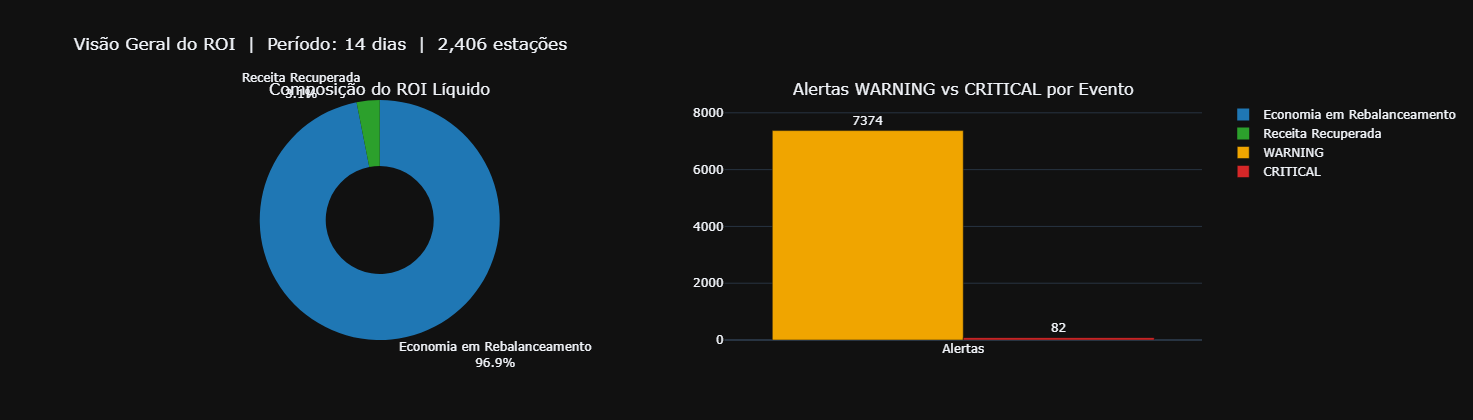

In [3]:
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "pie"}, {"type": "bar"}]],
    subplot_titles=("Composição do ROI Líquido", "Alertas WARNING vs CRITICAL por Evento"),
)

# Pizza — composição do ROI
fig.add_trace(go.Pie(
    labels=["Economia em Rebalanceamento", "Receita Recuperada"],
    values=[summary["meta_savings_on_rebalance_usd"], summary["kpi_recovered_revenue_usd"]],
    hole=0.45,
    marker_colors=["#1f77b4", "#2ca02c"],
    textinfo="percent+label",
), row=1, col=1)

# Barras — distribuição dos alertas
fig.add_trace(go.Bar(
    name="WARNING",
    x=["Alertas"],
    y=[summary["meta_alerts_warning_planned"]],
    marker_color="#f0a500",
    text=[summary["meta_alerts_warning_planned"]],
    textposition="outside",
), row=1, col=2)
fig.add_trace(go.Bar(
    name="CRITICAL",
    x=["Alertas"],
    y=[summary["meta_alerts_critical_emergency"]],
    marker_color="#d62728",
    text=[summary["meta_alerts_critical_emergency"]],
    textposition="outside",
), row=1, col=2)

fig.update_layout(
    height=420,
    title_text=f"Visão Geral do ROI  |  Período: {summary['meta_unique_days']} dias  |  {summary['meta_total_stations']:,} estações",
    barmode="group",
    showlegend=True,
    template="plotly_dark",
)
fig.show()

## 3. Top 20 Estações com Mais Alertas de Rebalanceamento

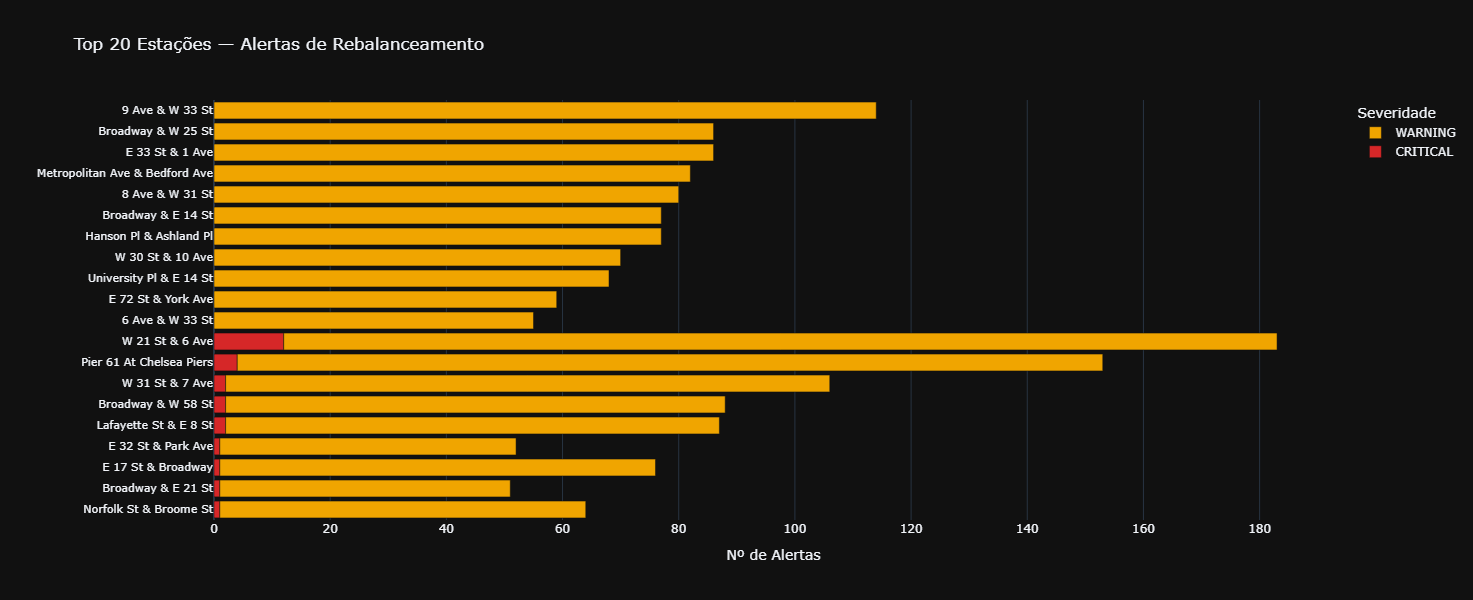

In [4]:
alert_counts = (
    df_reb.groupby(["station_name", "rebalance_alert"])
    .size().reset_index(name="count")
)
top20 = (
    alert_counts.groupby("station_name")["count"].sum()
    .nlargest(20).index
)
df_top = (
    alert_counts[alert_counts["station_name"].isin(top20)]
    .sort_values("count")
)

fig = px.bar(
    df_top,
    x="count", y="station_name", color="rebalance_alert",
    orientation="h",
    color_discrete_map={"WARNING": "#f0a500", "CRITICAL": "#d62728"},
    labels={"count": "Nº de Alertas", "station_name": "", "rebalance_alert": "Severidade"},
    title="Top 20 Estações — Alertas de Rebalanceamento",
    template="plotly_dark",
    height=600,
)
fig.update_layout(yaxis=dict(tickfont=dict(size=11)), legend_traceorder="reversed")
fig.show()

## 4. Receita Recuperada vs Ainda Perdida — Top 15 Estações Críticas

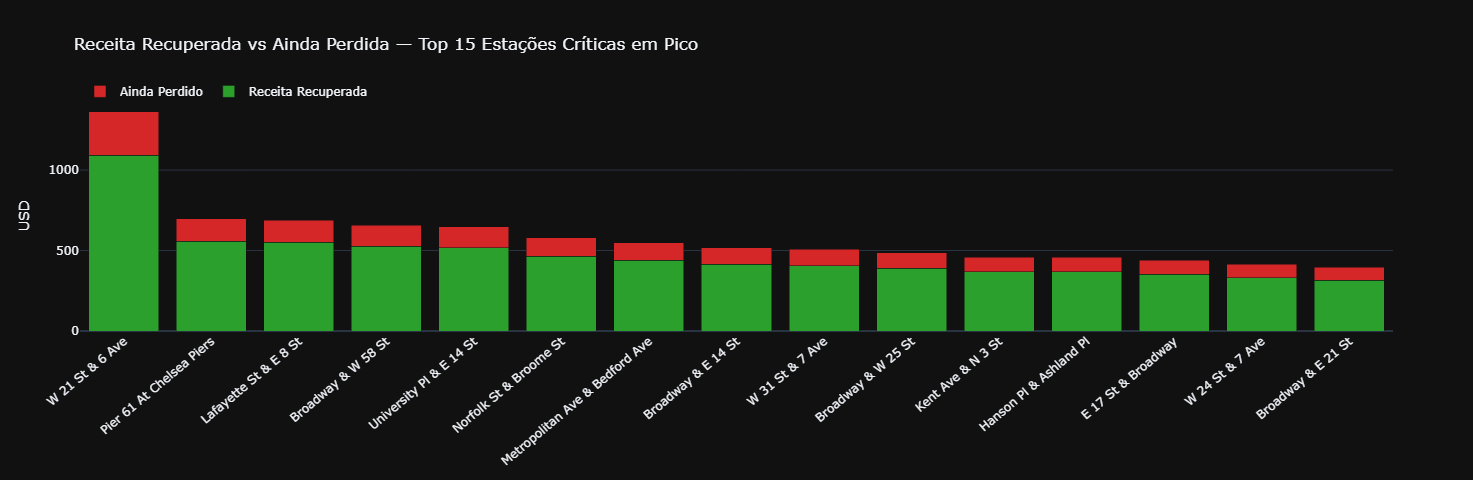

In [5]:
rev_sta = (
    df_rev.groupby("station_name")[["potential_lost_revenue_usd", "recovered_revenue_usd"]]
    .sum().reset_index()
    .sort_values("potential_lost_revenue_usd", ascending=False)
    .head(15)
)
rev_sta["ainda_perdido_usd"] = rev_sta["potential_lost_revenue_usd"] - rev_sta["recovered_revenue_usd"]

fig = go.Figure()
fig.add_trace(go.Bar(
    name="Receita Recuperada",
    x=rev_sta["station_name"], y=rev_sta["recovered_revenue_usd"],
    marker_color="#2ca02c",
))
fig.add_trace(go.Bar(
    name="Ainda Perdido",
    x=rev_sta["station_name"], y=rev_sta["ainda_perdido_usd"],
    marker_color="#d62728",
))
fig.update_layout(
    barmode="stack",
    title="Receita Recuperada vs Ainda Perdida — Top 15 Estações Críticas em Pico",
    xaxis_tickangle=-40,
    yaxis_title="USD",
    template="plotly_dark",
    height=480,
    legend=dict(orientation="h", y=1.1),
)
fig.show()

## 5. Perfil de Demanda por Hora do Dia

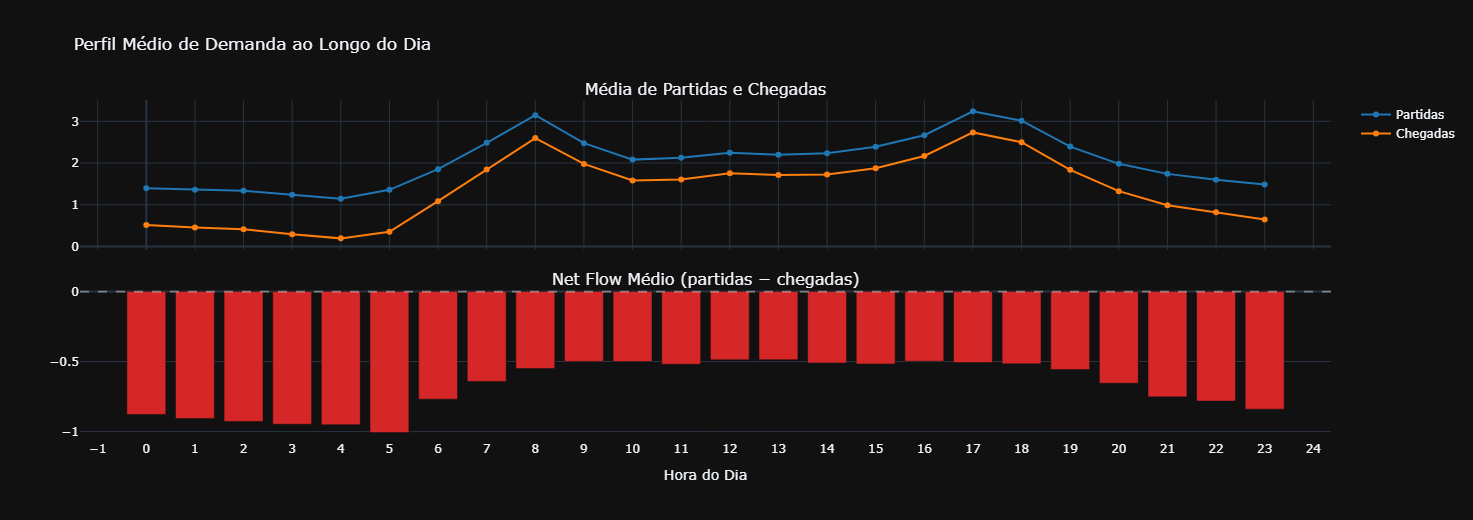

In [6]:
hourly = (
    df_hourly.groupby("hour_of_day")[["departures", "arrivals", "net_flow"]]
    .mean().reset_index()
)

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=("Média de Partidas e Chegadas", "Net Flow Médio (partidas − chegadas)"),
                    vertical_spacing=0.12)

fig.add_trace(go.Scatter(
    x=hourly["hour_of_day"], y=hourly["departures"],
    name="Partidas", mode="lines+markers", line=dict(color="#1f77b4", width=2),
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=hourly["hour_of_day"], y=hourly["arrivals"],
    name="Chegadas", mode="lines+markers", line=dict(color="#ff7f0e", width=2),
), row=1, col=1)

fig.add_trace(go.Bar(
    x=hourly["hour_of_day"], y=hourly["net_flow"],
    name="Net Flow",
    marker_color=["#d62728" if v < 0 else "#2ca02c" for v in hourly["net_flow"]],
    showlegend=False,
), row=2, col=1)
fig.add_hline(y=0, line_dash="dash", line_color="white", opacity=0.4, row=2, col=1)

fig.update_layout(
    height=520,
    title="Perfil Médio de Demanda ao Longo do Dia",
    xaxis2_title="Hora do Dia",
    template="plotly_dark",
)
fig.update_xaxes(tickmode="linear", dtick=1)
fig.show()

## 6. Impacto do Clima na Demanda

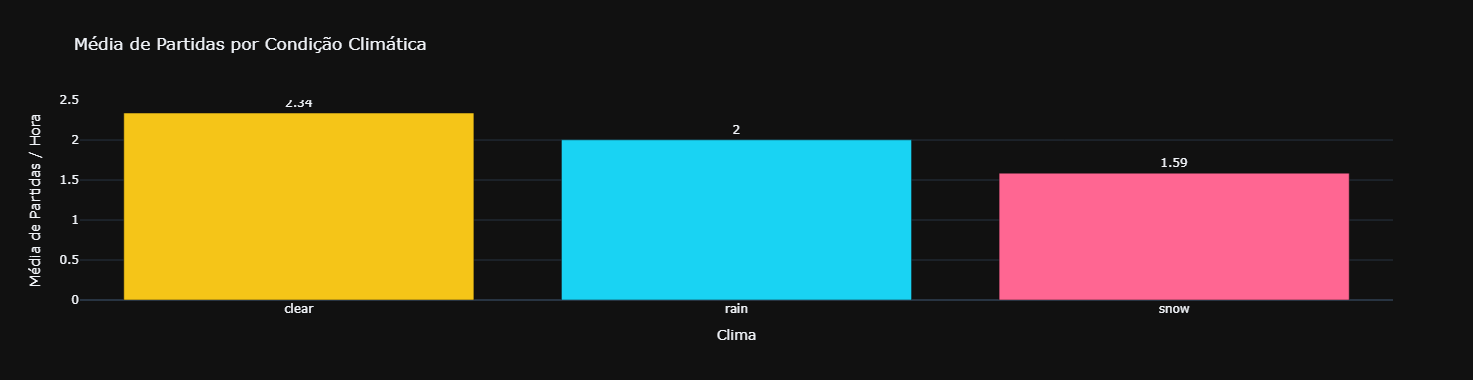

In [7]:
weather_agg = (
    df_hourly.groupby("weather_category")[["departures"]]
    .agg(["mean", "sum", "count"])
    .reset_index()
)
weather_agg.columns = ["weather_category", "avg_departures", "total_departures", "n_hours"]
weather_agg = weather_agg.sort_values("avg_departures", ascending=False)

color_weather = {
    "clear":  "#f5c518",
    "cloudy": "#90a4ae",
    "rainy":  "#1565c0",
    "snowy":  "#b3e5fc",
    "stormy": "#6a1b9a",
}

fig = px.bar(
    weather_agg,
    x="weather_category", y="avg_departures",
    color="weather_category",
    color_discrete_map=color_weather,
    text=weather_agg["avg_departures"].round(2),
    title="Média de Partidas por Condição Climática",
    labels={"weather_category": "Clima", "avg_departures": "Média de Partidas / Hora"},
    template="plotly_dark",
    height=380,
)
fig.update_traces(textposition="outside")
fig.update_layout(showlegend=False)
fig.show()

## 7. Detalhe por Estação

=== W 21 St & 6 Ave ===
Alertas de rebalanceamento : 183
  CRITICAL : 12
Economia gerada            : $ 30,096.00
Janelas de crise em pico   : 71
Receita recuperada         : $ 1,090.80


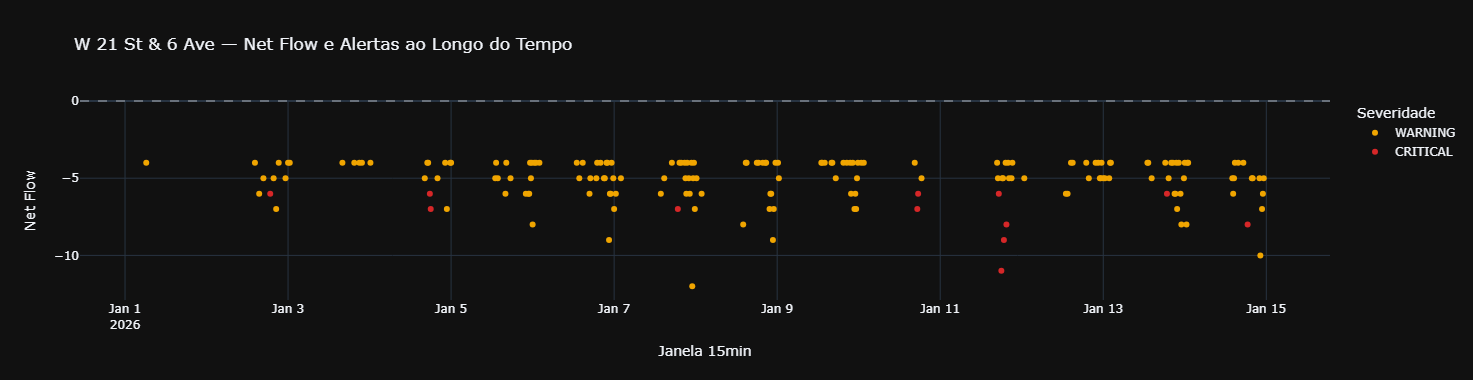

In [8]:
# Altere o nome da estação abaixo para explorar qualquer estação
STATION = "W 21 St & 6 Ave"

df_s_reb = df_reb[df_reb["station_name"] == STATION].sort_values("window_15min")
df_s_rev = df_rev[df_rev["station_name"] == STATION].sort_values("window_15min")

if df_s_reb.empty and df_s_rev.empty:
    print(f"Nenhum dado encontrado para '{STATION}'. Verifique o nome da estação.")
else:
    print(f"=== {STATION} ===")
    print(f"Alertas de rebalanceamento : {len(df_s_reb):,}")
    print(f"  WARNING  : {(df_s_reb['rebalance_alert']=='WARNING').sum():,}")
    print(f"  CRITICAL : {(df_s_reb['rebalance_alert']=='CRITICAL').sum():,}")
    print(f"Economia gerada            : $ {df_s_reb['saving_usd'].sum():,.2f}")
    print(f"Janelas de crise em pico   : {len(df_s_rev):,}")
    print(f"Receita recuperada         : $ {df_s_rev['recovered_revenue_usd'].sum():,.2f}")

    if not df_s_reb.empty:
        fig = px.scatter(
            df_s_reb,
            x="window_15min", y="net_flow",
            color="rebalance_alert",
            color_discrete_map={"WARNING": "#f0a500", "CRITICAL": "#d62728"},
            title=f"{STATION} — Net Flow e Alertas ao Longo do Tempo",
            labels={"window_15min": "Janela 15min", "net_flow": "Net Flow",
                    "rebalance_alert": "Severidade"},
            template="plotly_dark",
            height=380,
        )
        fig.add_hline(y=0, line_dash="dash", line_color="white", opacity=0.3)
        fig.show()